In [1]:
import pandas as pd

In [44]:
df = pd.read_csv("../data/processed/training_dataset.csv")
df


,datetime,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,...,pm25_lag_48,pm25_lag_72,pm25_lag_168,pm25_roll_mean_24,pm25_roll_std_24,pm25_roll_mean_72,pm25_roll_std_72,temp_humidity,wind_pm25,target_pm25
0,2023-01-08 00:00:00,17.1,38,2.5,13.1,0.0,0.0,1018.9,0,16.1,...,40.4,37.5,36.6,50.045833,5.475874,46.791667,5.383301,649.8,710.01,40.9
1,2023-01-08 01:00:00,16.6,39,2.6,12.5,0.0,0.0,1018.6,0,16.2,...,41.6,36.9,33.5,50.012500,5.506464,46.901389,5.257898,647.4,725.76,34.7
2,2023-01-08 02:00:00,16.3,40,2.5,12.2,0.0,0.0,1018.3,0,16.1,...,43.2,37.4,38.8,49.991667,5.520075,47.025000,5.134549,652.0,745.43,32.0
3,2023-01-08 03:00:00,16.0,40,2.4,11.9,0.0,0.0,1018.0,0,16.1,...,45.4,38.5,40.7,50.008333,5.516924,47.173611,5.038276,640.0,792.12,30.5
4,2023-01-08 04:00:00,15.8,40,2.2,11.5,0.0,0.0,1017.8,0,16.8,...,47.7,39.6,45.5,50.025000,5.521598,47.341667,4.983600,632.0,868.56,30.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26059,2025-12-28 19:00:00,22.0,45,9.5,20.9,0.0,0.0,1014.2,47,6.6,...,52.9,43.0,19.6,41.658333,14.719136,43.797222,11.678595,990.0,438.24,31.4
26060,2025-12-28 20:00:00,21.1,48,9.7,20.1,0.0,0.0,1014.8,9,6.4,...,53.6,42.1,17.3,42.337500,15.255927,44.066667,11.861252,1012.8,393.60,30.3
26061,2025-12-28 21:00:00,20.4,52,10.1,19.4,0.0,0.0,1015.1,18,7.0,...,52.4,40.2,16.1,43.087500,15.464189,44.283333,11.931896,1060.8,390.60,29.2
26062,2025-12-28 22:00:00,20.1,53,10.3,19.1,0.0,0.0,1015.3,0,6.8,...,50.4,37.4,15.3,43.854167,15.377510,44.472222,11.929042,1065.3,346.80,27.9


In [3]:
df.shape

(26064, 38)

In [27]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'rain', 'surface_pressure',
       'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'pm25', 'pm10',
       'no2', 'so2', 'co', 'o3', 'year', 'month', 'day', 'hour', 'weekday',
       'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'pm25_lag_24', 'pm25_lag_48', 'pm25_lag_72', 'pm25_lag_168',
       'pm25_roll_mean_24', 'pm25_roll_std_24', 'pm25_roll_mean_72',
       'pm25_roll_std_72', 'temp_humidity', 'wind_pm25', 'target_pm25'],
      dtype='str')

In [4]:
df.isnull().sum()

datetime                0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
rain                    0
surface_pressure        0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
pm25                    0
pm10                    0
no2                     0
so2                     0
co                      0
o3                      0
year                    0
month                   0
day                     0
hour                    0
weekday                 0
is_weekend              0
hour_sin                0
hour_cos                0
month_sin               0
month_cos               0
pm25_lag_24             0
pm25_lag_48             0
pm25_lag_72             0
pm25_lag_168            0
pm25_roll_mean_24       0
pm25_roll_std_24        0
pm25_roll_mean_72       0
pm25_roll_std_72        0
temp_humidity           0
wind_pm25               0
target_pm25             0
dtype: int64

## Imports for Data Visualization


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')


## Data Preprocessing
Convert `datetime` column to pandas datetime object and set it as index.


In [13]:
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)


In [16]:
print(df.dtypes)

temperature_2m          float64
relative_humidity_2m      int64
dew_point_2m            float64
apparent_temperature    float64
precipitation           float64
rain                    float64
surface_pressure        float64
cloud_cover               int64
wind_speed_10m          float64
wind_direction_10m        int64
pm25                    float64
pm10                    float64
no2                     float64
so2                     float64
co                      float64
o3                      float64
year                      int64
month                     int64
day                       int64
hour                      int64
weekday                   int64
is_weekend                int64
hour_sin                float64
hour_cos                float64
month_sin               float64
month_cos               float64
pm25_lag_24             float64
pm25_lag_48             float64
pm25_lag_72             float64
pm25_lag_168            float64
pm25_roll_mean_24       float64
pm25_rol

## Summary Statistics


In [14]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
temperature_2m,26064.0,2.657680e+01,4.826898,8.900000,23.900000,2.740000e+01,29.900000,41.600000
relative_humidity_2m,26064.0,6.570135e+01,21.695596,5.000000,51.000000,7.000000e+01,83.000000,100.000000
dew_point_2m,26064.0,1.854868e+01,8.138748,-18.200000,13.700000,2.210000e+01,24.700000,28.600000
apparent_temperature,26064.0,2.846506e+01,6.843365,3.000000,24.100000,3.050000e+01,33.500000,44.700000
precipitation,26064.0,2.763198e-02,0.332299,0.000000,0.000000,0.000000e+00,0.000000,16.500000
rain,26064.0,2.763198e-02,0.332299,0.000000,0.000000,0.000000e+00,0.000000,16.500000
surface_pressure,26064.0,1.007905e+03,6.773249,990.200000,1002.500000,1.008100e+03,1013.800000,1023.400000
cloud_cover,26064.0,3.382773e+01,39.836385,0.000000,0.000000,1.200000e+01,74.000000,100.000000
wind_speed_10m,26064.0,1.478603e+01,7.220567,0.000000,9.400000,1.360000e+01,19.400000,46.600000
wind_direction_10m,26064.0,2.183851e+02,92.468026,1.000000,211.000000,2.490000e+02,271.000000,360.000000


## Target Variable Distribution (`target_pm25`)


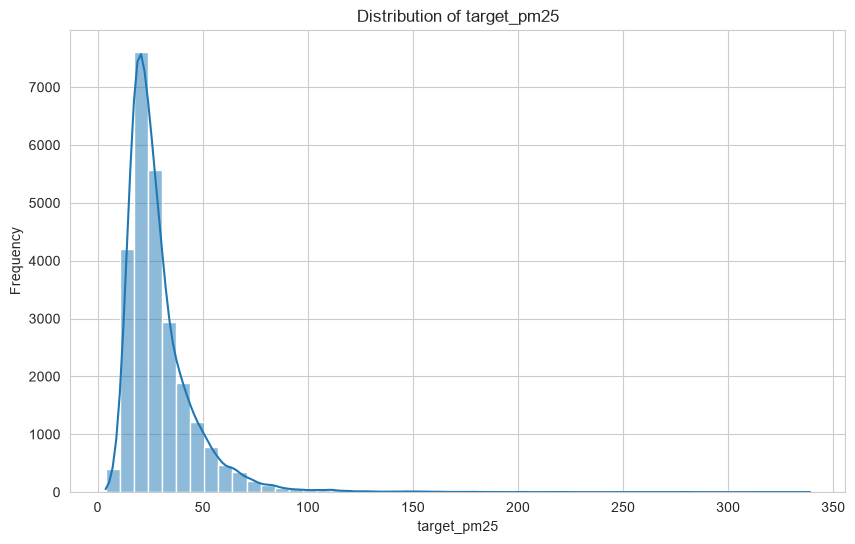

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['target_pm25'], bins=50, kde=True)
plt.title('Distribution of target_pm25')
plt.xlabel('target_pm25')
plt.ylabel('Frequency')
plt.show()


## Time Series Plot of target_pm25


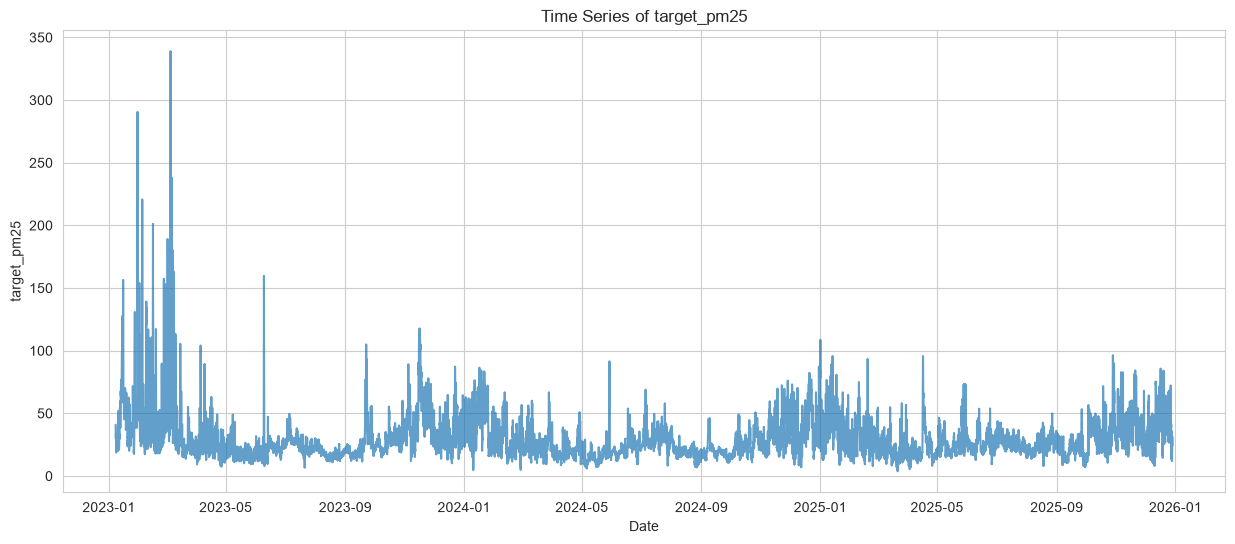

In [18]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['target_pm25'], alpha=0.7)
plt.title('Time Series of target_pm25')
plt.xlabel('Date')
plt.ylabel('target_pm25')
plt.show()


## Average target_pm25 by Hour of Day


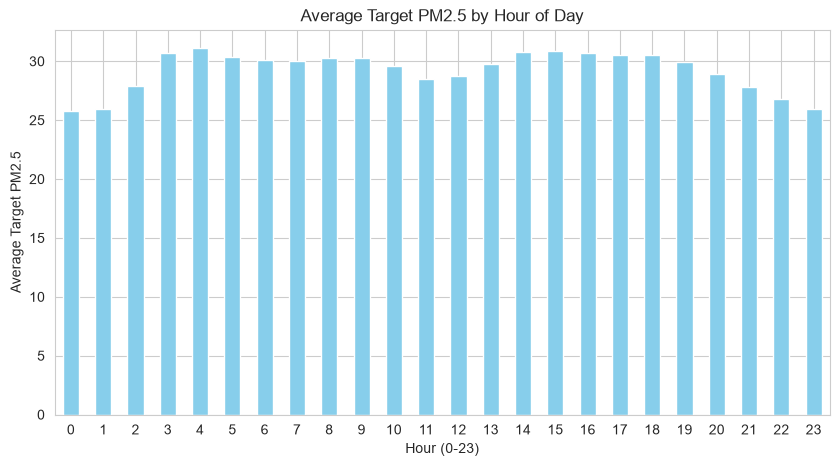

In [19]:
plt.figure(figsize=(10, 5))
df.groupby('hour')['target_pm25'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Target PM2.5 by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Average Target PM2.5')
plt.xticks(rotation=0)
plt.show()


## Average target_pm25 by Month


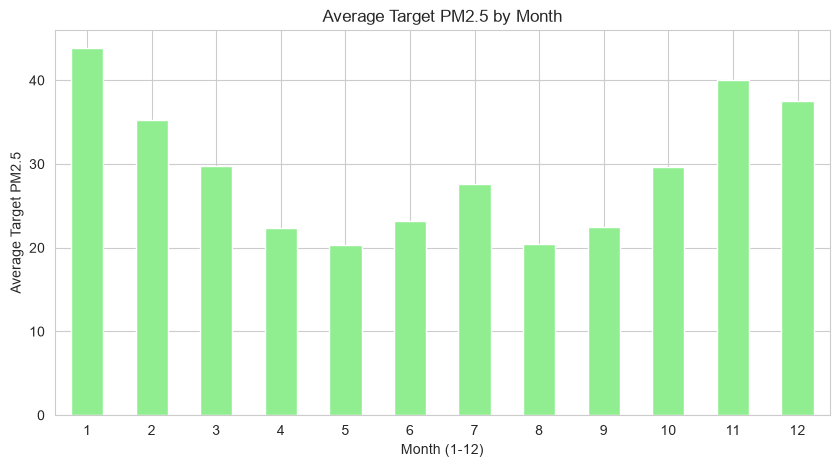

In [20]:
plt.figure(figsize=(10, 5))
df.groupby('month')['target_pm25'].mean().plot(kind='bar', color='lightgreen')
plt.title('Average Target PM2.5 by Month')
plt.xlabel('Month (1-12)')
plt.ylabel('Average Target PM2.5')
plt.xticks(rotation=0)
plt.show()


## Correlation Heatmap


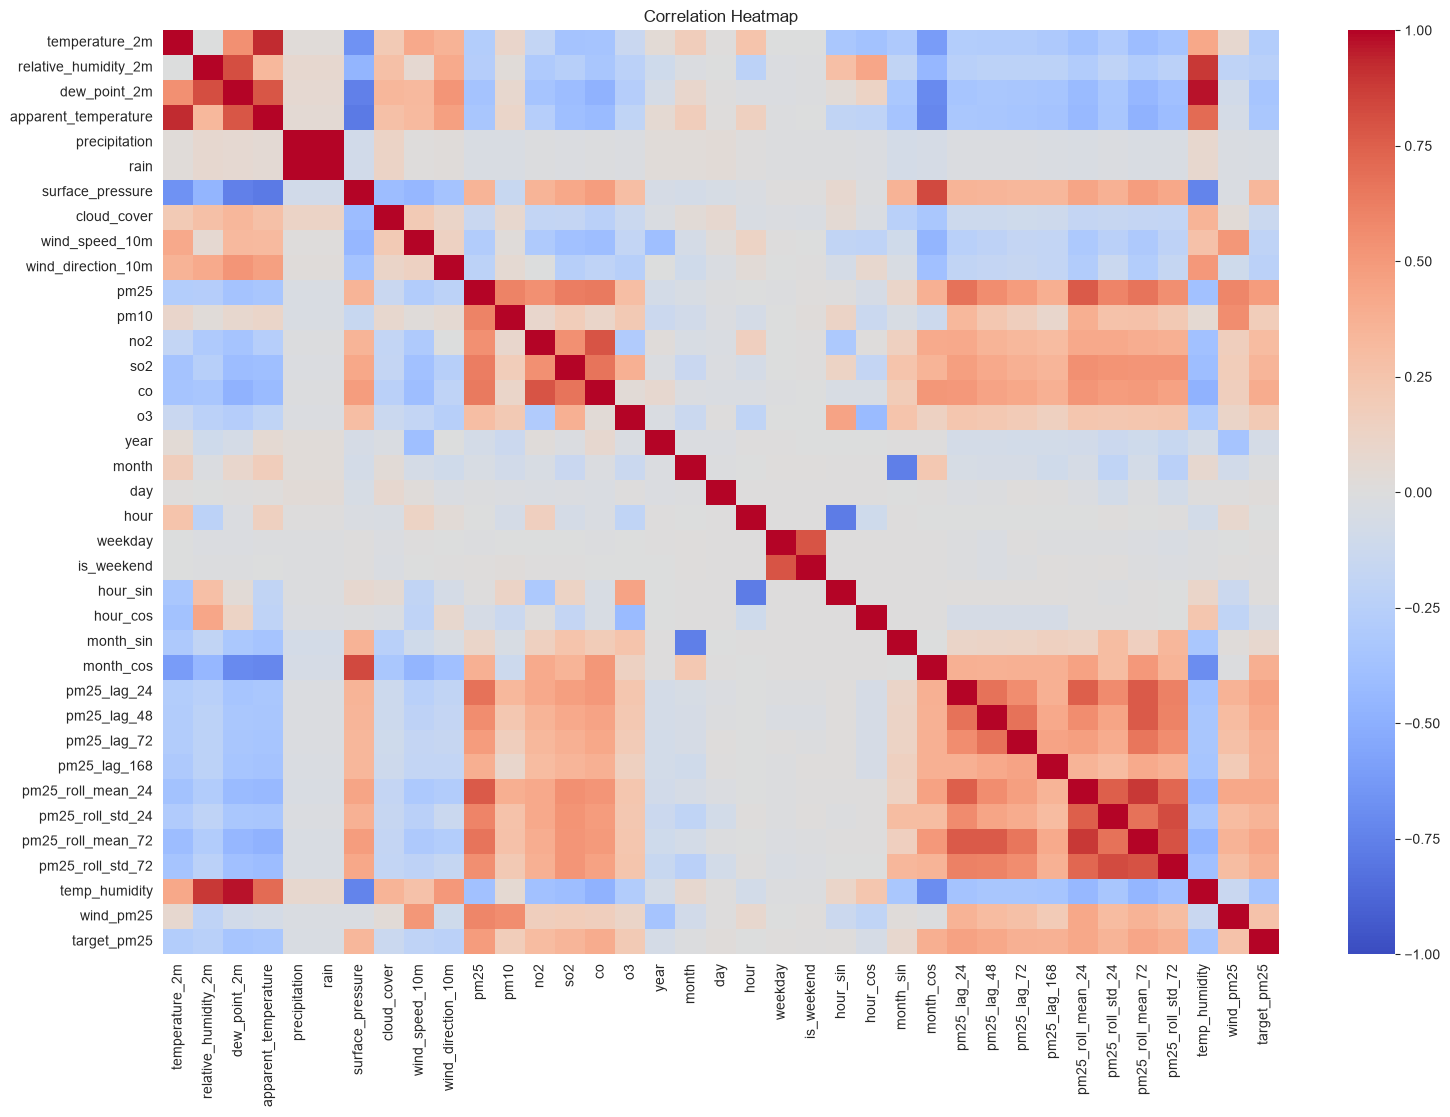

In [21]:
plt.figure(figsize=(18, 12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


## Top correlated features with target_pm25


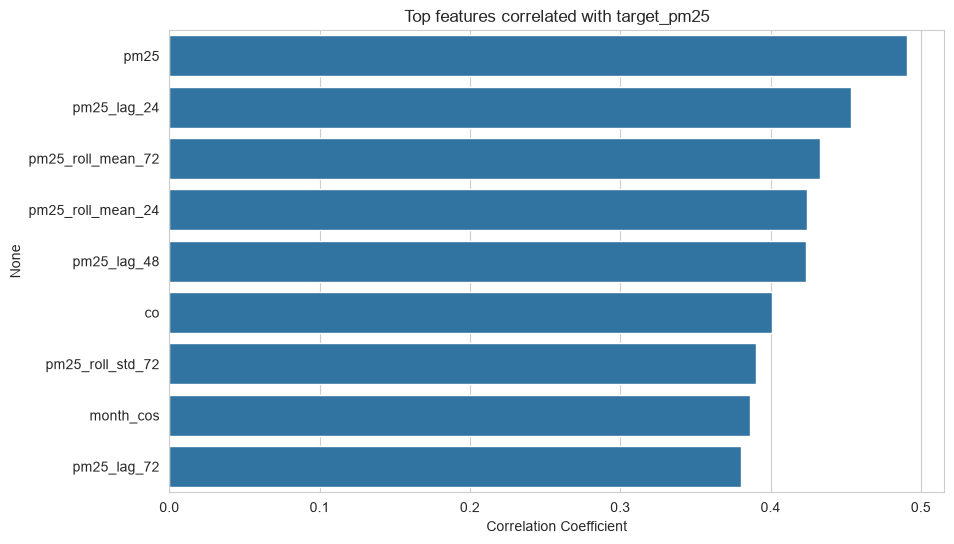

In [22]:
top_corr_features = corr['target_pm25'].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 6))
sns.barplot(x=corr.loc[top_corr_features, 'target_pm25'].values[1:], y=top_corr_features[1:])
plt.title('Top features correlated with target_pm25')
plt.xlabel('Correlation Coefficient')
plt.show()


## Scatter Plot: pm25 vs target_pm25


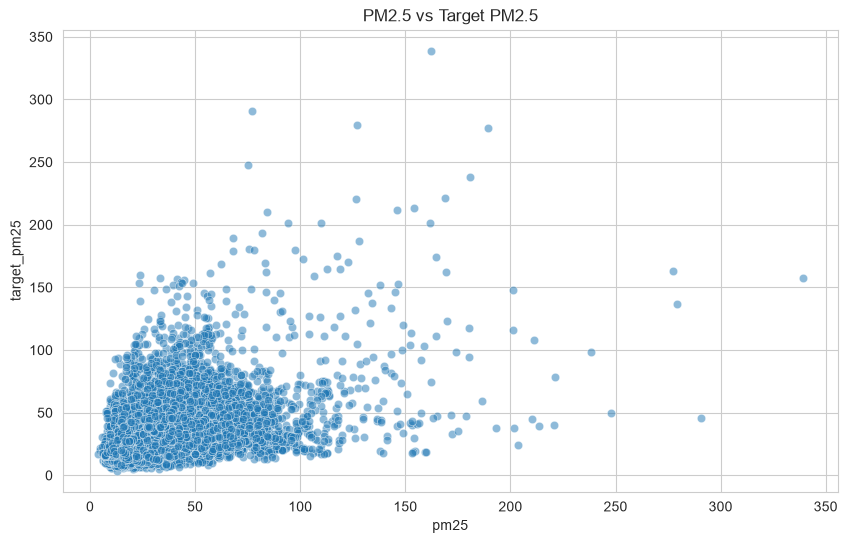

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pm25', y='target_pm25', data=df, alpha=0.5)
plt.title('PM2.5 vs Target PM2.5')
plt.show()


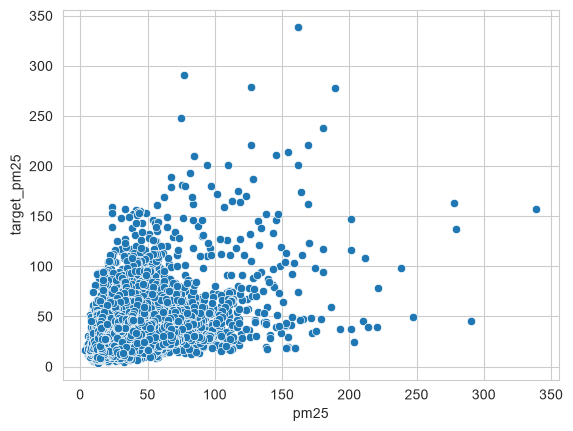

In [25]:
sns.scatterplot(data=df, x='pm25', y='target_pm25')
plt.show()

In [31]:
pearson = df.corr(method='pearson', numeric_only=True)['target_pm25']
spearman = df.corr(method='spearman', numeric_only=True)['target_pm25']

corr_df = pd.DataFrame({
    'Pearson': pearson,
    'Spearman': spearman
})

corr_df = corr_df.reindex(
    corr_df['Pearson'].abs().sort_values(ascending=False).index
)
corr_df

,Pearson,Spearman
target_pm25,1.000000,1.000000
pm25,0.491036,0.516254
pm25_lag_24,0.453374,0.474341
pm25_roll_mean_72,0.433089,0.492035
pm25_roll_mean_24,0.424370,0.474640
pm25_lag_48,0.423622,0.454881
co,0.400698,0.441741
pm25_roll_std_72,0.390431,0.423315
month_cos,0.386569,0.417734
pm25_lag_72,0.380025,0.426753


In [32]:
pearson = df.corr(method='pearson', numeric_only=True)
spearman = df.corr(method='spearman', numeric_only=True)

In [35]:
pearson

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,...,pm25_lag_48,pm25_lag_72,pm25_lag_168,pm25_roll_mean_24,pm25_roll_std_24,pm25_roll_mean_72,pm25_roll_std_72,temp_humidity,wind_pm25,target_pm25
temperature_2m,1.000000,-0.001631,0.545412,0.929553,0.026446,0.026446,-0.670489,0.203964,0.420057,0.361797,...,-0.282040,-0.285786,-0.311635,-0.373179,-0.292552,-0.413724,-0.352495,0.426993,0.073410,-0.274281
relative_humidity_2m,-0.001631,1.000000,0.813419,0.335696,0.070421,0.070421,-0.463556,0.278743,0.070121,0.407542,...,-0.224838,-0.224280,-0.220516,-0.287769,-0.210064,-0.285941,-0.226876,0.890059,-0.203193,-0.244487
dew_point_2m,0.545412,0.813419,1.000000,0.785178,0.066147,0.066147,-0.753235,0.339321,0.325388,0.520024,...,-0.334331,-0.338314,-0.351351,-0.428654,-0.333564,-0.452973,-0.383869,0.970908,-0.091523,-0.348598
apparent_temperature,0.929553,0.335696,0.785178,1.000000,0.050591,0.050591,-0.784712,0.275597,0.315761,0.465068,...,-0.336784,-0.344161,-0.364782,-0.434801,-0.341371,-0.477652,-0.411624,0.704752,-0.065151,-0.331808
precipitation,0.026446,0.070421,0.066147,0.050591,1.000000,1.000000,-0.092633,0.124178,0.012673,0.022762,...,-0.022702,-0.022447,-0.025134,-0.037094,-0.021431,-0.036171,-0.036619,0.078489,-0.027123,-0.036177
rain,0.026446,0.070421,0.066147,0.050591,1.000000,1.000000,-0.092633,0.124178,0.012673,0.022762,...,-0.022702,-0.022447,-0.025134,-0.037094,-0.021431,-0.036171,-0.036619,0.078489,-0.027123,-0.036177
surface_pressure,-0.670489,-0.463556,-0.753235,-0.784712,-0.092633,-0.092633,1.000000,-0.411559,-0.449682,-0.363895,...,0.349053,0.341047,0.343340,0.439682,0.371497,0.480267,0.422002,-0.738586,-0.026323,0.341397
cloud_cover,0.203964,0.278743,0.339321,0.275597,0.124178,0.124178,-0.411559,1.000000,0.205616,0.112958,...,-0.121626,-0.105369,-0.116855,-0.175355,-0.158924,-0.175320,-0.182033,0.355122,0.032106,-0.134641
wind_speed_10m,0.420057,0.070121,0.325388,0.315761,0.012673,0.012673,-0.449682,0.205616,1.000000,0.144186,...,-0.213413,-0.177383,-0.186237,-0.318303,-0.240003,-0.306269,-0.216194,0.272497,0.510718,-0.208364
wind_direction_10m,0.361797,0.407542,0.520024,0.465068,0.022762,0.022762,-0.363895,0.112958,0.144186,1.000000,...,-0.174919,-0.161666,-0.180847,-0.287124,-0.139361,-0.278030,-0.169322,0.501791,-0.106500,-0.227229


In [36]:
spearman

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,...,pm25_lag_48,pm25_lag_72,pm25_lag_168,pm25_roll_mean_24,pm25_roll_std_24,pm25_roll_mean_72,pm25_roll_std_72,temp_humidity,wind_pm25,target_pm25
temperature_2m,1.000000,-0.086871,0.544185,0.902190,0.145677,0.145677,-0.686139,0.251845,0.475252,0.048907,...,-0.275855,-0.281047,-0.305187,-0.342096,-0.415950,-0.391687,-0.449640,0.356003,0.202252,-0.248786
relative_humidity_2m,-0.086871,1.000000,0.705021,0.246032,0.132755,0.132755,-0.442143,0.335692,0.018211,0.339534,...,-0.261146,-0.254129,-0.253032,-0.330626,-0.346852,-0.337756,-0.361885,0.845778,-0.223240,-0.250970
dew_point_2m,0.544185,0.705021,1.000000,0.796981,0.234137,0.234137,-0.849539,0.462034,0.357314,0.220477,...,-0.381201,-0.380421,-0.391099,-0.466262,-0.553665,-0.512363,-0.595527,0.960539,-0.001652,-0.345705
apparent_temperature,0.902190,0.246032,0.796981,1.000000,0.173171,0.173171,-0.816119,0.340753,0.356607,0.126356,...,-0.333493,-0.341819,-0.366821,-0.402898,-0.496687,-0.460810,-0.541062,0.650760,0.042735,-0.297657
precipitation,0.145677,0.132755,0.234137,0.173171,1.000000,1.000000,-0.263513,0.300311,0.160198,-0.021825,...,-0.082461,-0.071394,-0.060038,-0.148769,-0.157196,-0.147799,-0.187340,0.216620,0.058691,-0.096323
rain,0.145677,0.132755,0.234137,0.173171,1.000000,1.000000,-0.263513,0.300311,0.160198,-0.021825,...,-0.082461,-0.071394,-0.060038,-0.148769,-0.157196,-0.147799,-0.187340,0.216620,0.058691,-0.096323
surface_pressure,-0.686139,-0.442143,-0.849539,-0.816119,-0.263513,-0.263513,1.000000,-0.465336,-0.465189,-0.158977,...,0.370547,0.368077,0.380256,0.460506,0.549174,0.512072,0.588092,-0.762433,-0.112021,0.353322
cloud_cover,0.251845,0.335692,0.462034,0.340753,0.300311,0.300311,-0.465336,1.000000,0.245459,0.039748,...,-0.151705,-0.143670,-0.157141,-0.217863,-0.306041,-0.230603,-0.327991,0.447578,0.078444,-0.153768
wind_speed_10m,0.475252,0.018211,0.357314,0.356607,0.160198,0.160198,-0.465189,0.245459,1.000000,0.015394,...,-0.287953,-0.255494,-0.241121,-0.405163,-0.426413,-0.401092,-0.398419,0.259196,0.633799,-0.264212
wind_direction_10m,0.048907,0.339534,0.220477,0.126356,-0.021825,-0.021825,-0.158977,0.039748,0.015394,1.000000,...,-0.115573,-0.114237,-0.135947,-0.201005,-0.152774,-0.199168,-0.177482,0.273734,-0.116320,-0.155278
